In [8]:
# import sys
# !{sys.executable} -m pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 10.2 MB/s eta 0:00:00a 0:00:01
Using cached tzdata-2026.2-py2.py3-none-any.whl (349 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [seaborn]m3/4 [seaborn]

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


*Importaciones*

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import shutil
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, Conv2D, MaxPool2D, Input
from skimage.io import imread, imshow
from tensorflow.keras.preprocessing.image import ImageDataGenerator


I0000 00:00:1781230715.698258    8932 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781230715.699996    8932 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781230716.426877    8932 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781230722.529236    8932 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [15]:
train_dir = "/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/datos/kagglecatsanddogs_5340/PetImages"
d = {"dogs": 0, "cats": 1}
for dir in os.listdir(train_dir):
    path = os.path.join(train_dir, dir)
    d[dir] = len(os.listdir(path))
print(d)

{'dogs': 0, 'cats': 1, 'Cat': 12501, 'Dog': 12501}


/tmp/ipykernel_84363/2591956987.py:1: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(imread("/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/datos/kagglecatsanddogs_5340/PetImages/Cat/1000.jpg"))


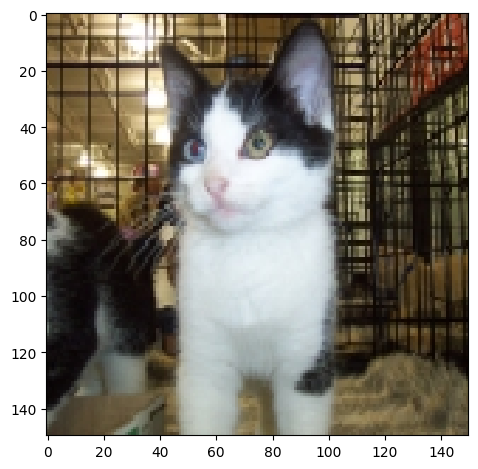

In [16]:
imshow(imread("/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/datos/kagglecatsanddogs_5340/PetImages/Cat/1000.jpg"))

/tmp/ipykernel_84363/898593285.py:1: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(imread("/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/datos/kagglecatsanddogs_5340/PetImages/Cat/1020.jpg"))


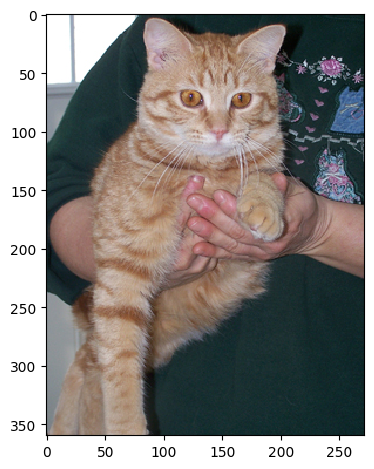

In [17]:
imshow(imread("/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/datos/kagglecatsanddogs_5340/PetImages/Cat/1020.jpg"))

/tmp/ipykernel_84363/1123294375.py:1: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(imread("/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/datos/kagglecatsanddogs_5340/PetImages/Dog/1000.jpg"))


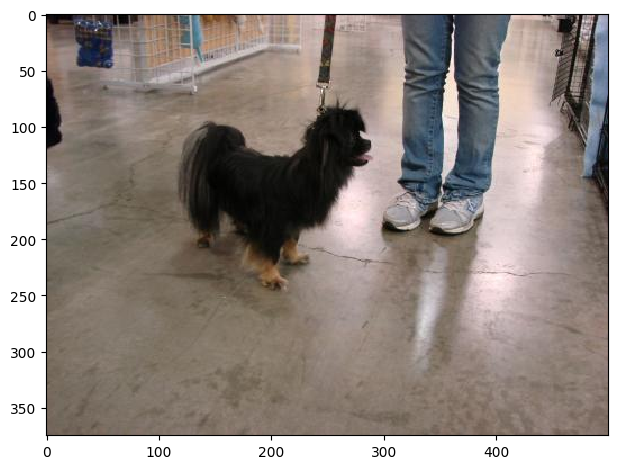

In [18]:
imshow(imread("/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/datos/kagglecatsanddogs_5340/PetImages/Dog/1000.jpg"))

In [3]:
# es importante tener el train_dir para que cuando se quiera ejecutar solo esta linea no me lance el error
ROOT_DIR = "/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/datos/cats_dogs"
train_dir = "/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/datos/kagglecatsanddogs_5340/PetImages"

# se crea la estructura principal
for carpeta in ['train', 'test', 'val']:
    os.makedirs(os.path.join(ROOT_DIR, carpeta), exist_ok=True)

# se crean subcarpetas Cat y Dog
for clase in os.listdir(train_dir):
    for carpeta in ['train', 'test', 'val']:
        os.makedirs(
            os.path.join(ROOT_DIR, carpeta, clase),
            exist_ok=True
        )

# es importante no hacer os.remove(...) porque se eliminarían los archivos originales, y rompe el dataset original, como alternativa se puede usar shutil.copyfile(...) para copiar los archivos a las nuevas carpetas, y así mantener el dataset original intacto

In [4]:
# se comprueba que los datos siguen intactos
for clase in os.listdir(train_dir):
    print(clase)

for clase in os.listdir(train_dir):
    print(clase, len(os.listdir(os.path.join(train_dir, clase))))

Cat
Dog
Cat 12501
Dog 12501


In [7]:
# se va a crea la division de los datos
for clase in os.listdir(train_dir):

    source_dir = os.path.join(train_dir, clase)

    imagenes = os.listdir(source_dir)

    np.random.shuffle(imagenes)

    total = len(imagenes)

    train_size = int(total * 0.8)
    val_size = int(total * 0.1)

    train_imgs = imagenes[:train_size]
    val_imgs = imagenes[train_size:train_size + val_size]
    test_imgs = imagenes[train_size + val_size:]

    print(f"\n{clase}")
    print(f"Train: {len(train_imgs)}")
    print(f"Val:   {len(val_imgs)}")
    print(f"Test:  {len(test_imgs)}")


Cat
Train: 10000
Val:   1250
Test:  1251

Dog
Train: 10000
Val:   1250
Test:  1251


In [8]:
# copiar los archivos a las nuevas carpetas
for clase in os.listdir(train_dir):

    source_dir = os.path.join(train_dir, clase)

    imagenes = os.listdir(source_dir)

    np.random.shuffle(imagenes)

    total = len(imagenes)

    train_size = int(total * 0.8)
    val_size = int(total * 0.1)

    train_imgs = imagenes[:train_size]
    val_imgs = imagenes[train_size:train_size + val_size]
    test_imgs = imagenes[train_size + val_size:]

    print(f"\n{clase}")
    print(f"Train: {len(train_imgs)}")
    print(f"Val:   {len(val_imgs)}")
    print(f"Test:  {len(test_imgs)}")

    # Train
    for img in train_imgs:
        shutil.copy2(
            os.path.join(source_dir, img),
            os.path.join(ROOT_DIR, "train", clase, img)
        )

    # Validation
    for img in val_imgs:
        shutil.copy2(
            os.path.join(source_dir, img),
            os.path.join(ROOT_DIR, "val", clase, img)
        )

    # Test
    for img in test_imgs:
        shutil.copy2(
            os.path.join(source_dir, img),
            os.path.join(ROOT_DIR, "test", clase, img)
        )


Cat
Train: 10000
Val:   1250
Test:  1251

Dog
Train: 10000
Val:   1250
Test:  1251


In [ ]:
# comprobar que los datos se han copiado correctamente
for carpeta in ['train', 'val', 'test']:
    print(f"\n{carpeta}")

    for clase in ['Cat', 'Dog']:
        ruta = os.path.join(ROOT_DIR, carpeta, clase)
        print(clase, len(os.listdir(ruta)))


train
Cat 10000
Dog 10000

val
Cat 1250
Dog 1250

test
Cat 1251
Dog 1251


In [ ]:
# .flow_from_directory - busca las carpetas de clases, detecta las imagenes, asigna etiquetas, las redimensiona a 224x224, normaliza pixeles y entrega en lotes para entrenar en CNN
traindatagenerator = ImageDataGenerator(rescale=1.0/255, rotation_range=0.3, zoom_range=0.2, horizontal_flip=True, vertical_flip=True)
train_data = traindatagenerator.flow_from_directory(directory = '/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/datos/cats_dogs/train', class_mode = 'binary', target_size = (224, 224))

Found 19999 images belonging to 2 classes.


In [16]:
valdatagenerator = ImageDataGenerator(rescale=1.0/255)
val_data = valdatagenerator.flow_from_directory(directory = '/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/datos/cats_dogs/val', class_mode = 'binary', target_size = (224, 224))

Found 2500 images belonging to 2 classes.


In [17]:
testdatagenerator = ImageDataGenerator(rescale=1.0/255)
test_data = testdatagenerator.flow_from_directory(directory = '/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/datos/cats_dogs/test', class_mode = 'binary', target_size = (224, 224))

Found 2501 images belonging to 2 classes.


In [13]:
train_data.class_indices

{'Cat': 0, 'Dog': 1}

In [14]:
CLASS_ID = { j:i for i, j in train_data.class_indices.items() }

In [18]:
CLASS_ID


{0: 'Cat', 1: 'Dog'}

In [ ]:
# conv2d - crea 16 filtros que recorren la imagen buscando patrones, maxpool2d - reduce la dimension de la imagen, dropout, flatten, dense 
model = Sequential ()
model.add(Conv2D(filters=16, kernel_size=(3,3), activation='relu', input_shape=(224, 224, 3)))

model.add((Conv2D(filters=16, kernel_size=(3,3), activation='relu')))
model.add(MaxPool2D(pool_size=(2, 2)))

model.add((Conv2D(filters=32, kernel_size=(3,3), activation='relu')))
model.add(MaxPool2D(pool_size=(2, 2)))

model.add((Conv2D(filters=64, kernel_size=(3,3), activation='relu')))
model.add(MaxPool2D(pool_size=(2, 2)))

model.add((Conv2D(filters=128, kernel_size=(3,3), activation='relu')))
model.add(MaxPool2D(pool_size=(2, 2)))

model.add(Dropout(rate = 0.4))

model.add(Flatten())

model.add(Dense(units=64, activation='relu'))
model.add(Dropout(rate = 0.4))
model.add(Dense(units=1, activation='sigmoid'))

model.summary()

/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/tf_env/lib64/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1781233520.601297    8932 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 52, 52, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,179,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,279,537 (4.88 MB)

 Trainable params: 1,279,537 (4.88 MB)

 Non-trainable params: 0 (0.00 B)

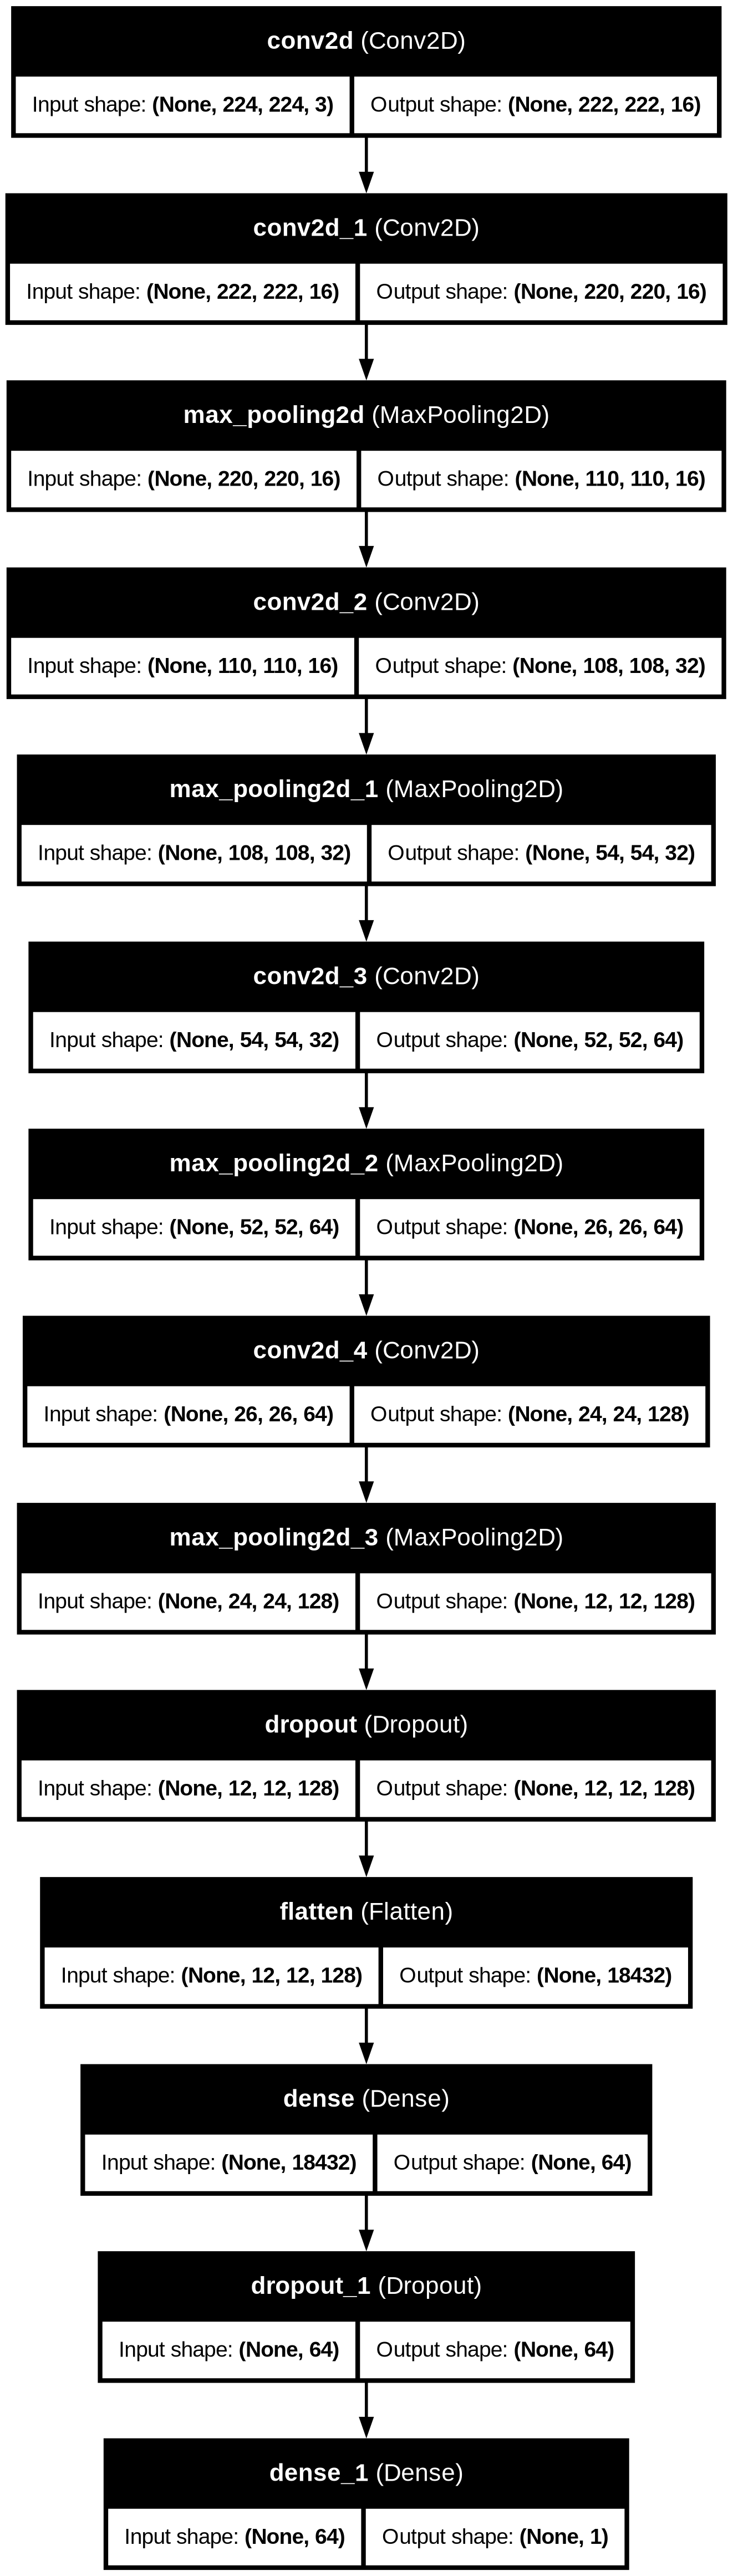

In [22]:
tf.keras.utils.plot_model(model, show_shapes=True, show_layer_names=True)